# ThinkMoney: Modelo Híbrido de Clusterização de Personas Financeiras

## Estrutura do Notebook
- **Bloco 1: Preparação dos Dados** (compartilhado entre K-Means++ e DBSCAN)
- **Bloco 2: DBSCAN**
- **Bloco 3: K-Means++**

## Bloco 1: Preparação dos Dados
### 1.1 Importação de Bibliotecas

In [1]:
%pip install pandas numpy shap openpyxl matplotlib seaborn scikit-learn joblib pyarrow hdbscan


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Bibliotecas de manipulação de dados
import pandas as pd
import numpy as np
import shap
import openpyxl

# Bibliotecas de visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("Bibliotecas carregadas com sucesso!")

c:\Users\ailto\OneDrive\Documentos\BSI UFRPE\2026.1 - 3ºPeríodo\PISI3\MachineLearning_PISI3\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Bibliotecas carregadas com sucesso!


In [3]:
import os
print(os.getcwd())
import os
os.listdir()


c:\Users\ailto\OneDrive\Documentos\BSI UFRPE\2026.1 - 3ºPeríodo\PISI3\MachineLearning_PISI3\modelos\modelo_clusterizacao


['analise_credito_personas.md',
 'calc_hybrid_metrics.py',
 'clusterizacao_hibrida_hdbscan.ipynb',
 'clusterizacao_personas_final.Ipynb',
 'data.parquet',
 'modelo_kmeans_personas.pkl']

### 1.2 Carregamento e Inspeção Inicial do Dataset

In [4]:
df = pd.read_parquet('data.parquet')

print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
print(f"\nColunas disponíveis:\n{df.columns.tolist()}")

Linhas: 20000
Colunas: 27

Colunas disponíveis:
['Income', 'Age', 'Dependents', 'Occupation', 'City_Tier', 'Rent', 'Loan_Repayment', 'Insurance', 'Groceries', 'Transport', 'Eating_Out', 'Entertainment', 'Utilities', 'Healthcare', 'Education', 'Miscellaneous', 'Desired_Savings_Percentage', 'Desired_Savings', 'Disposable_Income', 'Potential_Savings_Groceries', 'Potential_Savings_Transport', 'Potential_Savings_Eating_Out', 'Potential_Savings_Entertainment', 'Potential_Savings_Utilities', 'Potential_Savings_Healthcare', 'Potential_Savings_Education', 'Potential_Savings_Miscellaneous']


### 1.3 Feature Engineering — Variáveis Proporcionais

As variáveis financeiras foram transformadas em ratios proporcionais à renda (*ratio features*), eliminando a dominância do Income e permitindo que o modelo capture padrões comportamentais independentes do nível de renda.

O conjunto de 13 variáveis brutas a serem tratadas estão alinhadas com o escopo de variáveis base do modelo de classificação, porém com adição de City_Tier, Loan_Repayment, Eating_Out, Entertainment, Desired_Savings_Percentage e Disposable_Income.

Resultando em 10 variáveis proporcionais: Rent_pct, Loan_Repayment_pct, Disposable_pct, Desired_Savings_pct, Age, Dependents, Gap_Poupanca (que mede a diferença entre a expectativa e a realidade financeira), City_Tier_enc, Gastos_Consumo_pct, Gastos_Fixos_pct 

In [5]:
df_modelo = pd.DataFrame()

# --- Core compartilhado com modelo de classificação ---
# Mesmas variáveis do João, formato proporcional para capturar comportamento

df_modelo['Rent_pct']            = df['Rent'] / df['Income']
df_modelo['Loan_Repayment_pct']  = df['Loan_Repayment'] / df['Income']
df_modelo['Disposable_pct']      = df['Disposable_Income'] / df['Income']
df_modelo['Desired_Savings_pct'] = df['Desired_Savings_Percentage'] / 100
df_modelo['Age']                 = df['Age']
df_modelo['Dependents']          = df['Dependents']

# --- Variável exclusiva do modelo de clusterização ---
# Gap entre meta de poupança e capacidade real — não existe no João
# porque classificação não precisa dessa diferença, clusterização sim
df_modelo['Gap_Poupanca'] = (df['Desired_Savings_Percentage'] / 100) - \
                            (df['Disposable_Income'] / df['Income'])

# --- Variável de contexto urbano ---
df_modelo['City_Tier_enc']       = df['City_Tier'].map({'Tier_1': 3, 'Tier_2': 2, 'Tier_3': 1})

# --- Variáveis agregadas (reduzem ruído mantendo informação) ---
# Gastos de consumo: Groceries + Eating_Out + Entertainment
df_modelo['Gastos_Consumo_pct']  = (df['Groceries'] + df['Eating_Out'] +
                                     df['Entertainment']) / df['Income']

# Gastos fixos complementares: Insurance + Transport + Healthcare
df_modelo['Gastos_Fixos_pct']    = (df['Insurance'] + df['Transport'] +
                                     df['Healthcare']) / df['Income']

print(f"Total de variáveis: {df_modelo.shape[1]}")
print(df_modelo.columns.tolist())

Total de variáveis: 10
['Rent_pct', 'Loan_Repayment_pct', 'Disposable_pct', 'Desired_Savings_pct', 'Age', 'Dependents', 'Gap_Poupanca', 'City_Tier_enc', 'Gastos_Consumo_pct', 'Gastos_Fixos_pct']


### 1.4 Correlação entre Variáveis Proporcionais

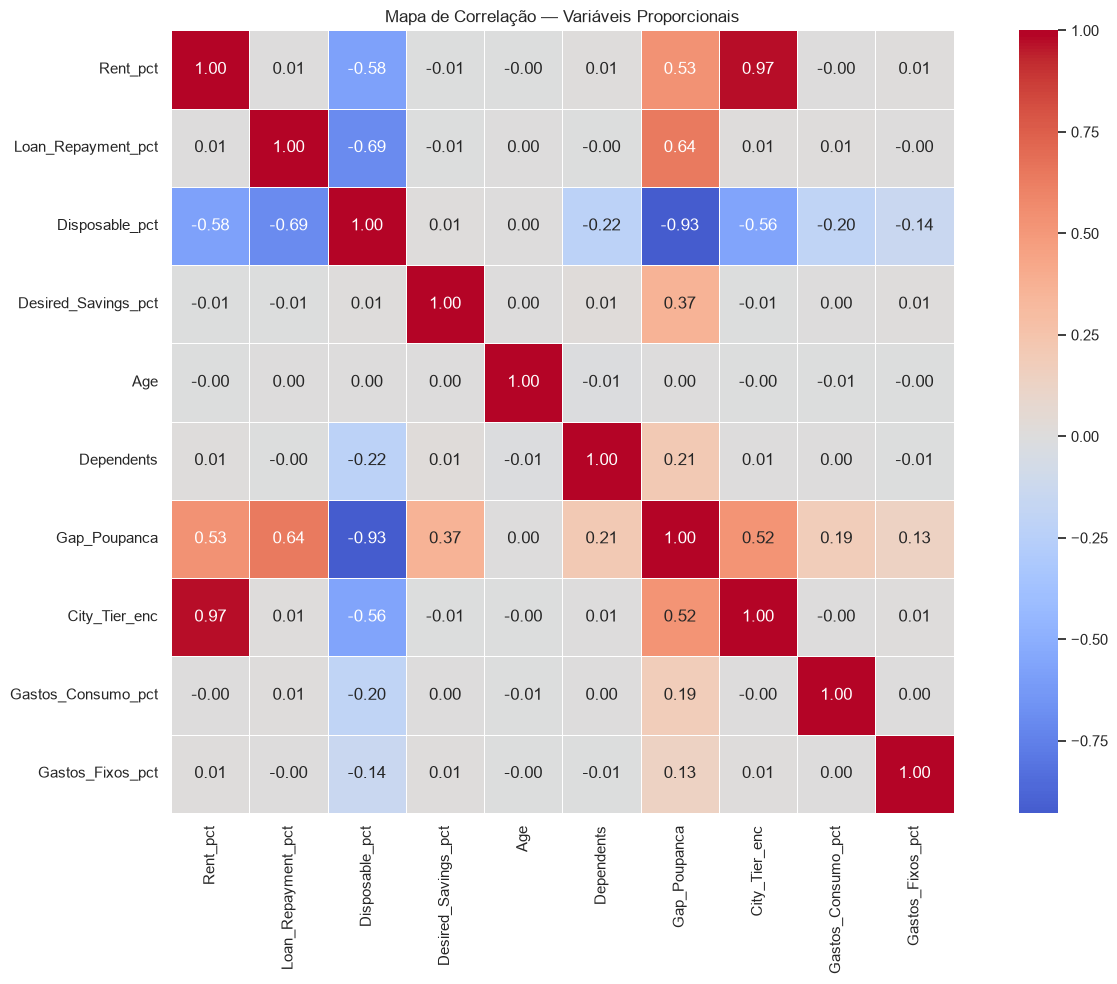

In [6]:
plt.figure(figsize=(14, 10))
colunas_corr = [c for c in df_modelo.columns if c != 'Cluster']
sns.heatmap(df_modelo[colunas_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Mapa de Correlação — Variáveis Proporcionais')
plt.tight_layout()
plt.show()

### 1.5 Normalização e Redução de Dimensionalidade

**RobustScaler**: normalização robusta a outliers, usando mediana e IQR em vez de média e desvio padrão.

**PCA**: redução de dimensionalidade preservando 85% da variância acumulada, justificada pelo número de variáveis e pela correlação residual entre elas.

In [7]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df_normalizado = scaler.fit_transform(df_modelo)

print("Dados normalizados com RobustScaler!")
print(f"Shape: {df_normalizado.shape}")

Dados normalizados com RobustScaler!
Shape: (20000, 10)


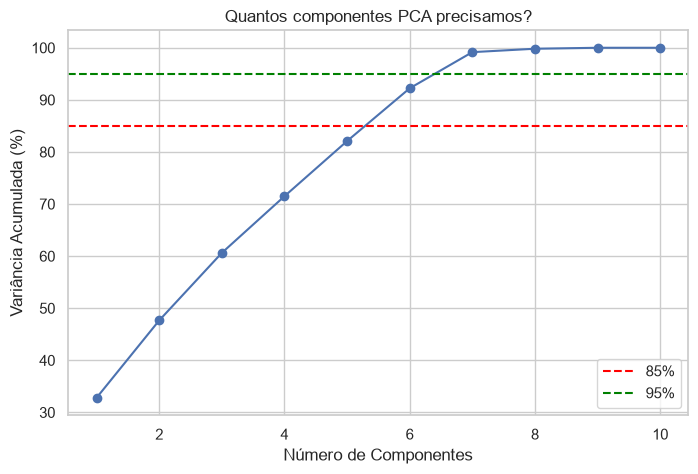

1 componentes: 32.8%
2 componentes: 47.7%
3 componentes: 60.6%
4 componentes: 71.5%
5 componentes: 82.1%
6 componentes: 92.2%
7 componentes: 99.2%
8 componentes: 99.8%
9 componentes: 100.0%
10 componentes: 100.0%


In [8]:
from sklearn.decomposition import PCA

pca_analise = PCA()
pca_analise.fit(df_normalizado)

variancia_acumulada = pca_analise.explained_variance_ratio_.cumsum()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(variancia_acumulada)+1), variancia_acumulada * 100, 'bo-')
plt.axhline(y=85, color='red', linestyle='--', label='85%')
plt.axhline(y=95, color='green', linestyle='--', label='95%')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Acumulada (%)')
plt.title('Quantos componentes PCA precisamos?')
plt.legend()
plt.grid(True)
plt.show()

for i, v in enumerate(variancia_acumulada):
    print(f"{i+1} componentes: {v*100:.1f}%")

In [9]:
# PCA com 85% de variância acumulada
pca = PCA(n_components=0.85, random_state=42)
df_pca = pca.fit_transform(df_normalizado)

print(f"Variância preservada: {sum(pca.explained_variance_ratio_)*100:.1f}%")
print(f"Shape: {df_pca.shape}")

Variância preservada: 92.2%
Shape: (20000, 6)


### 1.6 Visualização Exploratória: Espaço PCA 2D

Projeção dos dados nos dois primeiros componentes principais, antes da aplicação de qualquer algoritmo de clusterização.

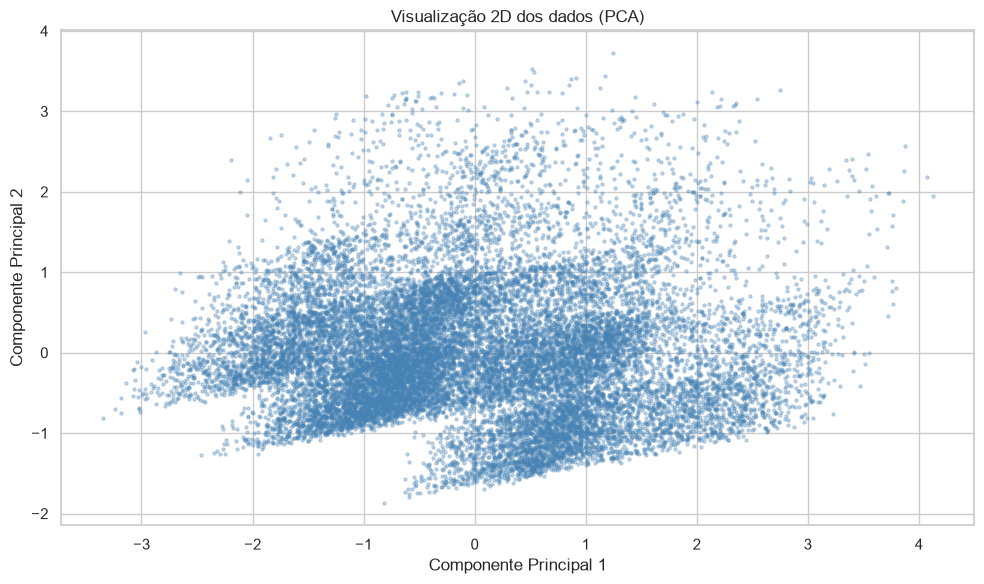

In [10]:
# Para visualizar usamos só 2 componentes
pca_2d = PCA(n_components=2, random_state=42)
df_pca_2d = pca_2d.fit_transform(df_normalizado)

plt.figure(figsize=(10, 6))
plt.scatter(df_pca_2d[:, 0], df_pca_2d[:, 1], alpha=0.3, s=5, color='steelblue')
plt.title('Visualização 2D dos dados (PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.tight_layout()
plt.show()

## Bloco 2: HDBSCAN

### 2.4 Validação de Min_Cluster_Size: DBCV vs. Ruído

Estou em dúvida de qual tamanho mínimo de cluster usar. Vou testar valores de 500 (2,5% da base) até 1000 (5% da base) , em intervalos de 100 e olhar os dados obtidos em tabela.

In [14]:
import numpy as np
import pandas as pd
from hdbscan import HDBSCAN
from IPython.display import display

# Range definido para testes: 500 a 900, pulando de 100 em 100
mcs_testes = range(500, 1100, 100) 
meu_min_samples = 12

resultados_hdbscan = []

for mcs_atual in mcs_testes:
    # Instancia o HDBSCAN com gen_min_span_tree=True para calcular a validade DBCV
    db = HDBSCAN(min_cluster_size=mcs_atual, min_samples=meu_min_samples, 
                 metric='euclidean', cluster_selection_method='eom', gen_min_span_tree=True)
    
    lbl = db.fit_predict(df_pca)
    
    # 1. Obter o score DBCV (relative_validity_)
    try:
        dbcv_score = db.relative_validity_
    except AttributeError:
        dbcv_score = np.nan
        
    # 2. Obter o percentual de Ruído
    total_samples = len(lbl)
    ruido = list(lbl).count(-1)
    perc_ruido = (ruido / total_samples) * 100
    
    # 3. Quantidade de clusters reais (ignorando ruído)
    n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
    
    resultados_hdbscan.append({
        'min_cluster_size': mcs_atual,
        'Qtd Clusters': n_clusters,
        'Ruído (%)': round(perc_ruido, 2),
        'DBCV Score': round(dbcv_score, 4) if not np.isnan(dbcv_score) else 'N/A'
    })

# Exibir os resultados como tabela comparativa
df_resultados_hdbscan = pd.DataFrame(resultados_hdbscan)

print("=== VALIDAÇÃO HDBSCAN: DBCV vs RUÍDO ===")
display(df_resultados_hdbscan)


=== VALIDAÇÃO HDBSCAN: DBCV vs RUÍDO ===


,min_cluster_size,Qtd Clusters,Ruído (%),DBCV Score
0,500,3,2.28,0.0024
1,600,3,2.28,0.0024
2,700,3,2.28,0.0024
3,800,3,2.28,0.0024
4,900,3,2.28,0.0024
5,1000,3,2.28,0.0024


Interpretação:
Os valores de 500 a 1000 (de 2,5% a 5% da base) geram sempre 3 clusters e tem valores iguais.

### 2.5 Modelo HDBSCAN Final

In [15]:
from IPython.display import display
from hdbscan import HDBSCAN
import numpy as np

# Treinamento do modelo HDBSCAN final
# Utilizamos min_cluster_size=500 (para evitar micro-clusters identificados no DBSCAN)
# e mantemos min_samples=12
hdbscan_final = HDBSCAN(min_cluster_size=500, min_samples=12, metric='euclidean', cluster_selection_method='eom')
labels_finais = hdbscan_final.fit_predict(df_pca)

df_final = df_modelo.copy()
df_final['Cluster_HDBSCAN'] = labels_finais

df_personas = df_final[df_final['Cluster_HDBSCAN'] != -1]

perfil_grupos = df_personas.groupby('Cluster_HDBSCAN').agg(
    Tamanho_do_Grupo=('Cluster_HDBSCAN', 'count'),
    **{col: (col, 'mean') for col in df_final.columns if col != 'Cluster_HDBSCAN'}
).sort_values(by='Tamanho_do_Grupo', ascending=False)

print("=== PERFIL DOS CLUSTERS PRINCIPAIS (HDBSCAN) ===")
display(perfil_grupos.round(2).T)

qtd_ruido = len(df_final[df_final['Cluster_HDBSCAN'] == -1])
print(f"\nOs {qtd_ruido} usuários de ruído (-1) foram isolados para não distorcer essas médias.")


=== PERFIL DOS CLUSTERS PRINCIPAIS (HDBSCAN) ===


Cluster_HDBSCAN,2,0,1
Tamanho_do_Grupo,9876.00,5920.00,3747.00
Rent_pct,0.20,0.30,0.15
Loan_Repayment_pct,0.05,0.05,0.05
Disposable_pct,0.28,0.17,0.33
Desired_Savings_pct,0.10,0.10,0.09
Age,41.01,41.03,41.14
Dependents,1.99,2.01,2.01
Gap_Poupanca,-0.18,-0.08,-0.24
City_Tier_enc,2.00,3.00,1.00
Gastos_Consumo_pct,0.20,0.20,0.20



Os 457 usuários de ruído (-1) foram isolados para não distorcer essas médias.


### 2.5.1 Análise de Resultados HDBSCAN
Abaixo, geramos estatísticas e visualizações para avaliar a qualidade dos clusters obtidos com o HDBSCAN e suas probabilidades.

Distribuição de pontos por cluster:
Cluster -1: 457 pontos (Ruído)
Cluster 0: 5920 pontos 
Cluster 1: 3747 pontos 
Cluster 2: 9876 pontos 


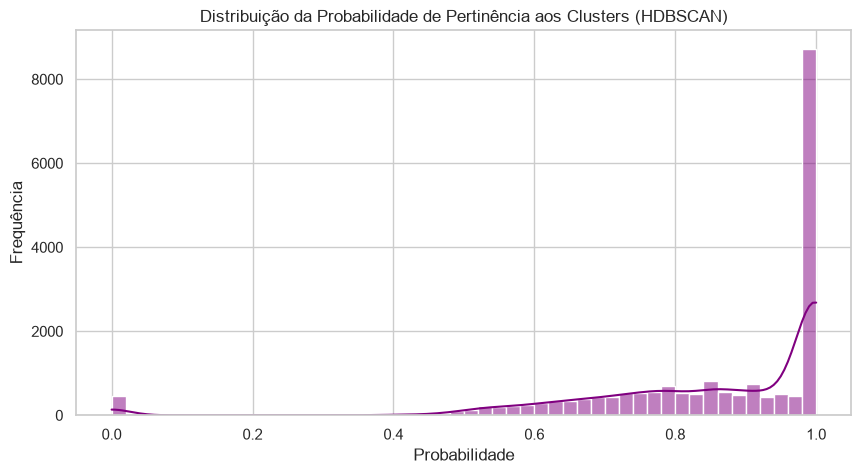

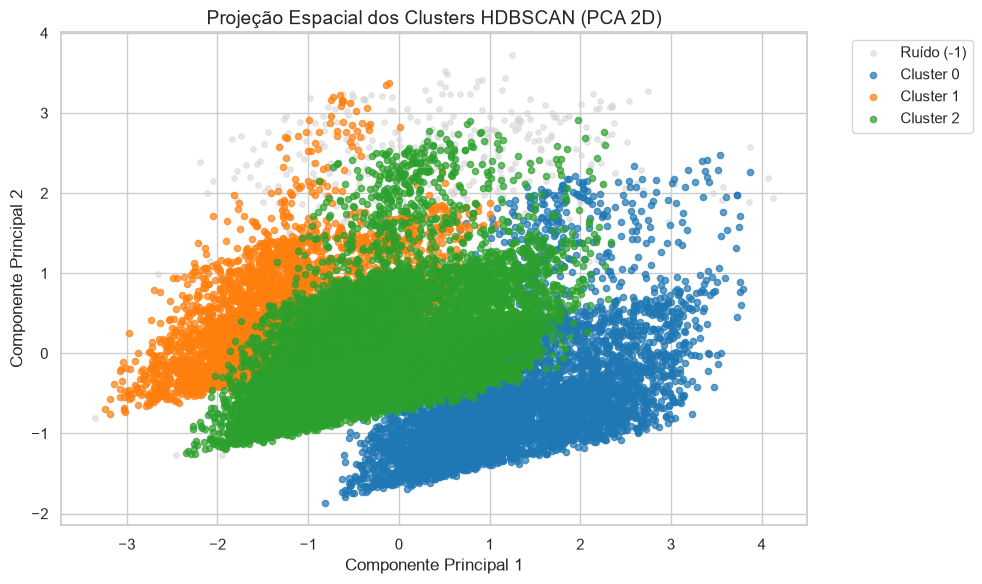

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Analisando a distribuição de tamanhos dos clusters
label_counts = Counter(labels_finais)
print("Distribuição de pontos por cluster:")
for cluster, count in sorted(label_counts.items()):
    print(f"Cluster {cluster}: {count} pontos {'(Ruído)' if cluster == -1 else ''}")

# Distribuição de probabilidades de pertinência ao cluster (probabilities_)
plt.figure(figsize=(10, 5))
sns.histplot(hdbscan_final.probabilities_, bins=50, kde=True, color='purple')
plt.title('Distribuição da Probabilidade de Pertinência aos Clusters (HDBSCAN)')
plt.xlabel('Probabilidade')
plt.ylabel('Frequência')
plt.show()

# Projeção PCA 2D dos Clusters
plt.figure(figsize=(10, 6))
clusters_unicos = sorted(df_final['Cluster_HDBSCAN'].unique())
paleta = {str(c): ('#d3d3d3' if c == -1 else sns.color_palette("tab10")[c % 10]) for c in clusters_unicos}

# Plot Ruído
plt.scatter(df_pca[df_final['Cluster_HDBSCAN'] == -1, 0],
            df_pca[df_final['Cluster_HDBSCAN'] == -1, 1],
            c='#d3d3d3', label='Ruído (-1)', alpha=0.5, s=15)

# Plot Clusters Reais
for c in clusters_unicos:
    if c != -1:
        plt.scatter(df_pca[df_final['Cluster_HDBSCAN'] == c, 0],
                    df_pca[df_final['Cluster_HDBSCAN'] == c, 1],
                    c=[paleta[str(c)]], label=f'Cluster {c}', alpha=0.7, s=20)

plt.title('Projeção Espacial dos Clusters HDBSCAN (PCA 2D)', fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


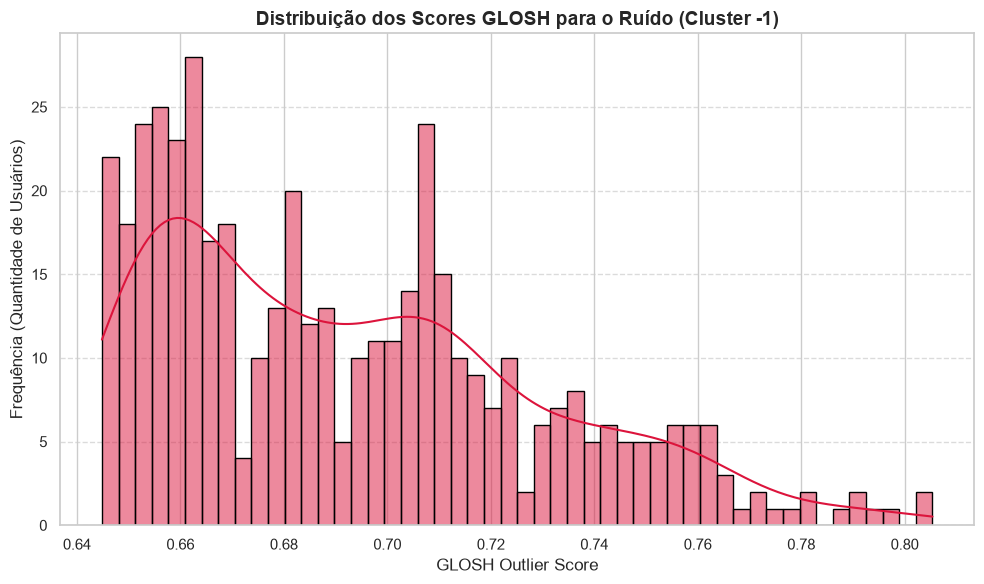

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extraindo os scores de anomalia (GLOSH) gerados pelo modelo
outlier_scores = hdbscan_final.outlier_scores_

# Criando uma máscara para pegar apenas os usuários que foram classificados como ruído
mascara_ruido = hdbscan_final.labels_ == -1
glosh_ruido = outlier_scores[mascara_ruido]

# Plotando o Histograma
plt.figure(figsize=(10, 6))
sns.histplot(glosh_ruido, bins=50, kde=True, color='crimson', edgecolor='black')

plt.title('Distribuição dos Scores GLOSH para o Ruído (Cluster -1)', fontsize=14, fontweight='bold')
plt.xlabel('GLOSH Outlier Score', fontsize=12)
plt.ylabel('Frequência (Quantidade de Usuários)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


### 2.6 Interpretabilidade — SHAP Values

#### 2.6.1 Gráfico do Princípio de Pareto por Cluster
Importância das variáveis para uma persona específica

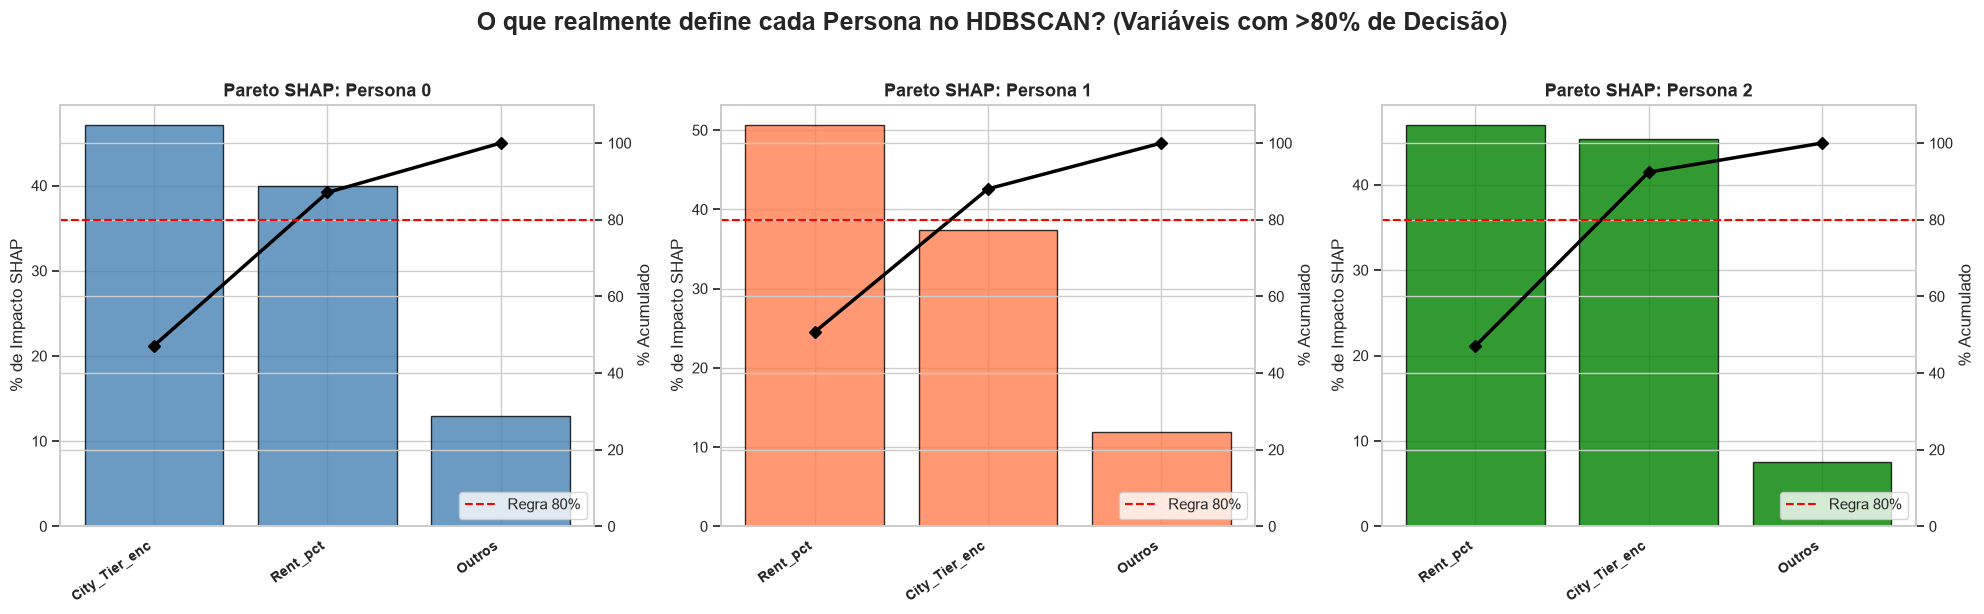

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import shap

# 1. Preparação dos dados: Garantir que estamos lidando apenas com clusters reais do HDBSCAN
try:
    # Tenta puxar as marcações do df_final (onde o HDBSCAN definitivo é salvo)
    _ = df_final['Cluster_HDBSCAN']
    df_base = df_final
except NameError:
    # Se df_final nem existir na memória
    if 'Cluster_HDBSCAN' in df_modelo.columns:
        df_base = df_modelo
    else:
        raise ValueError('Você precisa executar a célula que treina o Modelo HDBSCAN Final antes de rodar o gráfico de Pareto!')
except KeyError:
    # Se df_final existir mas não tiver a coluna
    if 'Cluster_HDBSCAN' in df_modelo.columns:
        df_base = df_modelo
    else:
        raise ValueError('Você precisa executar a célula que treina o Modelo HDBSCAN Final antes de rodar o gráfico de Pareto!')

df_limpo = df_base[df_base['Cluster_HDBSCAN'] != -1].copy()
y_alvo = df_base[df_base['Cluster_HDBSCAN'] != -1]['Cluster_HDBSCAN']

colunas_para_remover = ['Cluster_HDBSCAN', 'Cluster_DBSCAN', 'Cluster']
X = df_limpo.drop(columns=[col for col in colunas_para_remover if col in df_limpo.columns])
feature_names = X.columns

# Amostragem para performance do SHAP
tamanho_amostra = min(2000, len(X))
X_sample = X.sample(n=tamanho_amostra, random_state=42)
y_sample = y_alvo.loc[X_sample.index]

# Treinamento Rápido do Surrogate apenas para o Gráfico de Pareto
rf_pareto = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_pareto.fit(X_sample, y_sample)

# Geração dos Valores SHAP
explainer = shap.TreeExplainer(rf_pareto)
shap_valores = explainer.shap_values(X_sample)

# 2. Configuração do Grid de Gráficos (1 linha, 3 colunas para as 3 personas descobertas)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes = axes.flatten()

# 3. Cores oficiais do PCA 2D do HDBSCAN
cores_cluster = {0: 'steelblue', 1: 'coral', 2: 'green'}

# Itera apenas sobre os 3 clusters fixos do HDBSCAN (0, 1 e 2)
clusters_reais = [0, 1, 2]

for i, cluster_id in enumerate(clusters_reais):
    # Achar o índice numérico da classe no modelo Surrogate
    idx_classe = list(rf_pareto.classes_).index(cluster_id)
    
    # Extração robusta dos valores SHAP para a classe específica
    if isinstance(shap_valores, list):
        mean_abs_shap = np.abs(shap_valores[idx_classe]).mean(axis=0)
    elif len(np.array(shap_valores).shape) == 3:
        mean_abs_shap = np.abs(np.array(shap_valores)[:, :, idx_classe]).mean(axis=0)
    else:
        mean_abs_shap = np.abs(shap_valores[:, :, idx_classe]).mean(axis=0)

    # DataFrame de Importância Original (todas as variáveis)
    df_imp = pd.DataFrame({
        'Feature': feature_names,
        'Mean_Abs_SHAP': mean_abs_shap
    }).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

    # Matemática do Princípio de Pareto (Corte dos 80%)
    total_shap = df_imp['Mean_Abs_SHAP'].sum()
    df_imp['Percentual'] = (df_imp['Mean_Abs_SHAP'] / total_shap) * 100
    df_imp['Cumulativo'] = df_imp['Percentual'].cumsum()

    # Selecionamos as variáveis até que o cumulativo BATA ou PASSE de 80%
    cumsum_antes = df_imp['Percentual'].cumsum().shift(fill_value=0)
    linhas_principais = df_imp[cumsum_antes < 80].copy()
    linhas_outros = df_imp[~df_imp.index.isin(linhas_principais.index)]

    # Criar a barra 'Outros' se existirem variáveis de baixo impacto
    if not linhas_outros.empty:
        df_outros = pd.DataFrame({
            'Feature': ['Outros'],
            'Mean_Abs_SHAP': [linhas_outros['Mean_Abs_SHAP'].sum()],
            'Percentual': [linhas_outros['Percentual'].sum()],
            'Cumulativo': [100.0]
        })
        df_pareto = pd.concat([linhas_principais, df_outros], ignore_index=True)
    else:
        df_pareto = linhas_principais.copy()

    # Recalcular cumulativo final por segurança para o gráfico
    df_pareto['Cumulativo'] = df_pareto['Percentual'].cumsum()

    # --- Plotagem Individual do Subplot ---
    ax = axes[i]
    # Pega a cor oficial do dicionário PCA 2D
    cor_cluster = cores_cluster.get(cluster_id, 'gray')

    # Barras verticais (Importância Individual)
    ax.bar(range(len(df_pareto)), df_pareto['Percentual'], color=cor_cluster, alpha=0.8, edgecolor='black')

    # Eixo secundário (Curva do Pareto Cumulativo)
    ax2 = ax.twinx()
    ax2.plot(range(len(df_pareto)), df_pareto['Cumulativo'], color='black', marker='D', linewidth=2.5)

    # Linha Vermelha de Meta (80%)
    ax2.axhline(y=80, color='red', linestyle='--', linewidth=1.5, label='Regra 80%')

    # Formatação Visual do Subplot
    ax.set_xticks(range(len(df_pareto)))
    ax.set_xticklabels(df_pareto['Feature'], rotation=35, ha='right', fontsize=10, fontweight='bold')
    ax.set_title(f'Pareto SHAP: Persona {cluster_id}', fontweight='bold', fontsize=13)
    ax.set_ylabel('% de Impacto SHAP')
    ax2.set_ylabel('% Acumulado')
    ax2.set_ylim(0, 110)
    ax2.legend(loc='lower right')

plt.suptitle('O que realmente define cada Persona no HDBSCAN? (Variáveis com >80% de Decisão)',
             size=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 2.7 Radar Chart — Perfil Comportamental por Persona

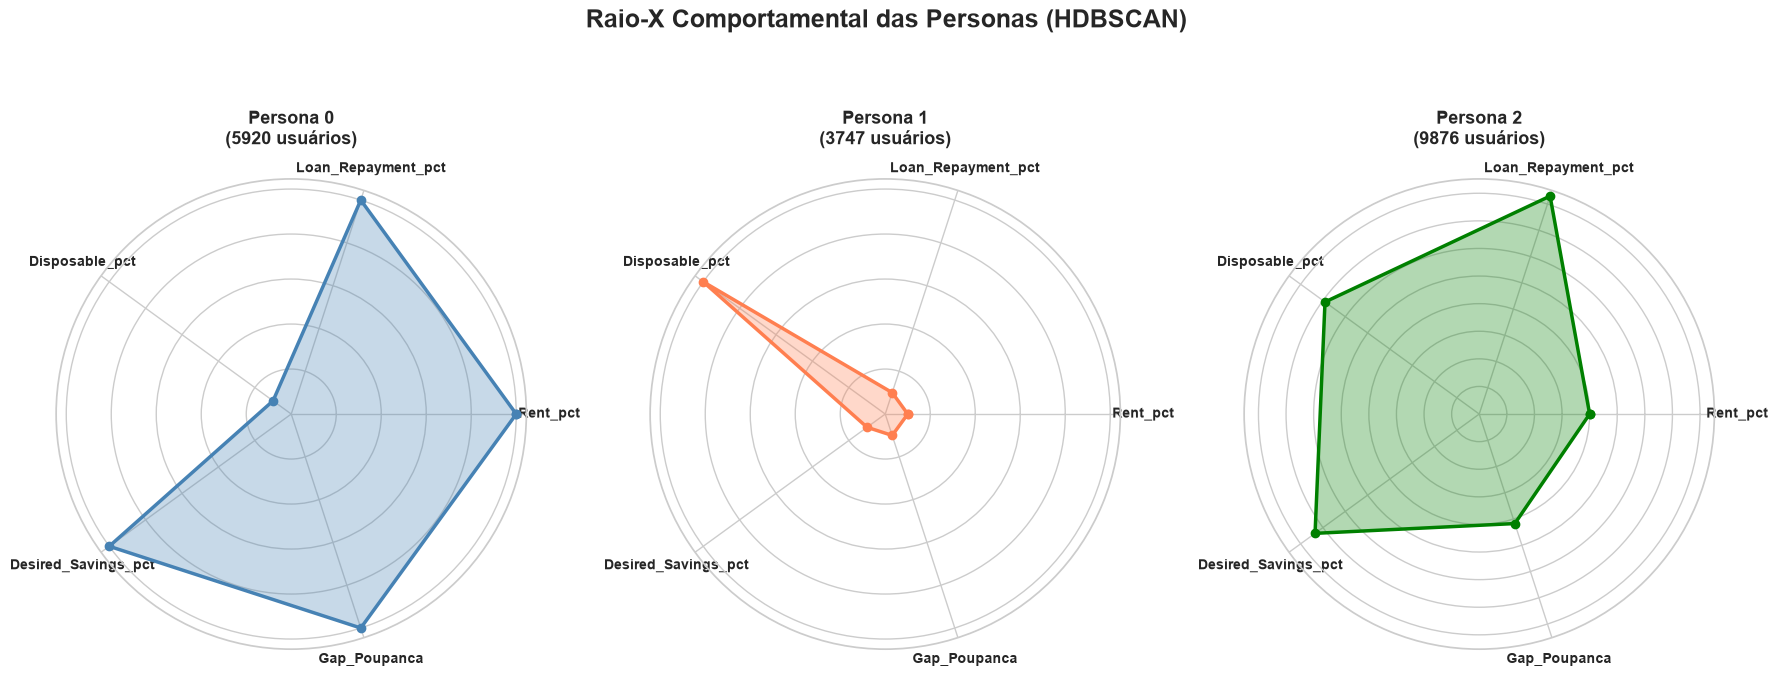

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Definir as categorias do Radar
categorias_radar = ['Rent_pct', 'Loan_Repayment_pct', 'Disposable_pct',
                    'Desired_Savings_pct', 'Gap_Poupanca']

# 2. Filtrar o ruído (-1) e calcular a média (perfil) e contagem de cada cluster real
df_limpo = df_final[df_final['Cluster_HDBSCAN'] != -1]
perfil_clusters = df_limpo.groupby('Cluster_HDBSCAN')[categorias_radar].mean()
contagem = df_limpo['Cluster_HDBSCAN'].value_counts().sort_index()

# 3. Normalização (MinMaxScaler) corrigida para comparar colunas (variáveis)
# O range (0.1, 1.0) evita que o menor valor suma no centro do gráfico (fique invisível)
scaler_radar = MinMaxScaler(feature_range=(0.1, 1.0))

# Sem a transposição, garantimos que o eixo de 'Rent' compare apenas 'Rent' entre os clusters
perfil_norm = pd.DataFrame(
    scaler_radar.fit_transform(perfil_clusters),
    index=perfil_clusters.index,
    columns=perfil_clusters.columns
)

# 4. Configuração da geometria do Radar (Ângulos e fechamento do polígono)
N = len(categorias_radar)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

# 5. Configuração do Grid de Gráficos (2 linhas, 3 colunas)
fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()

# Cores originais do seu projeto
cores = ['steelblue', 'coral', 'green', 'purple', 'orange']

# 6. Loop de plotagem dos 5 clusters
for i, cluster_id in enumerate(perfil_clusters.index):
    # Extrai os valores normalizados e duplica o primeiro no final para fechar o desenho
    valores = perfil_norm.loc[cluster_id].values.tolist()
    valores += valores[:1]

    # Desenha a linha e preenche o interior
    axes[i].plot(angles, valores, 'o-', linewidth=2.5, color=cores[i])
    axes[i].fill(angles, valores, alpha=0.3, color=cores[i])

    # Coloca os nomes das variáveis nas pontas do radar
    axes[i].set_xticks(angles[:-1])
    axes[i].set_xticklabels(categorias_radar, size=10, fontweight='bold')

    # Oculta os círculos numéricos internos (eixo Y) para um visual mais limpo e moderno
    axes[i].set_yticklabels([])

    # Título individual com a volumetria
    axes[i].set_title(f'Persona {cluster_id}\n({contagem[cluster_id]} usuários)',
                      size=13, fontweight='bold', pad=25)

# 7. Ocultar o 6º gráfico que sobra no grid
axes[3].set_visible(False)
axes[4].set_visible(False)
axes[5].set_visible(False)

plt.suptitle('Raio-X Comportamental das Personas (HDBSCAN)', size=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### 2.7.1. Beeswarm Global
Importância global das variáveis com direção de impacto — média sobre todas as classes.

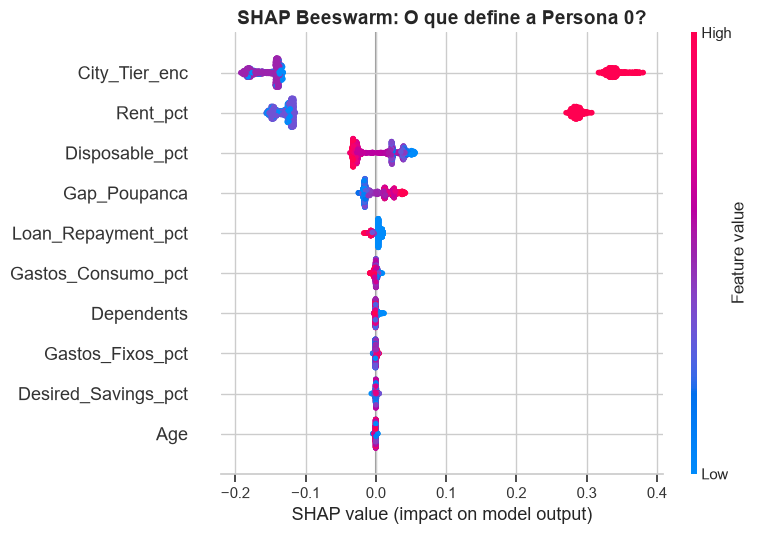

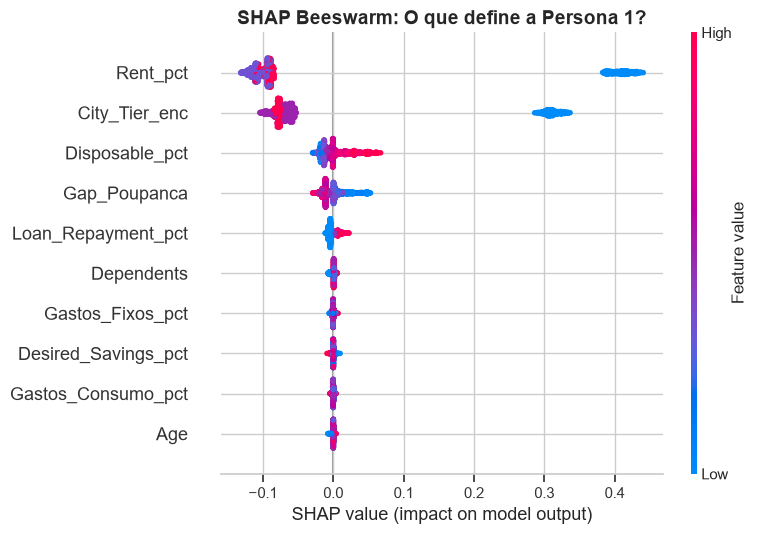

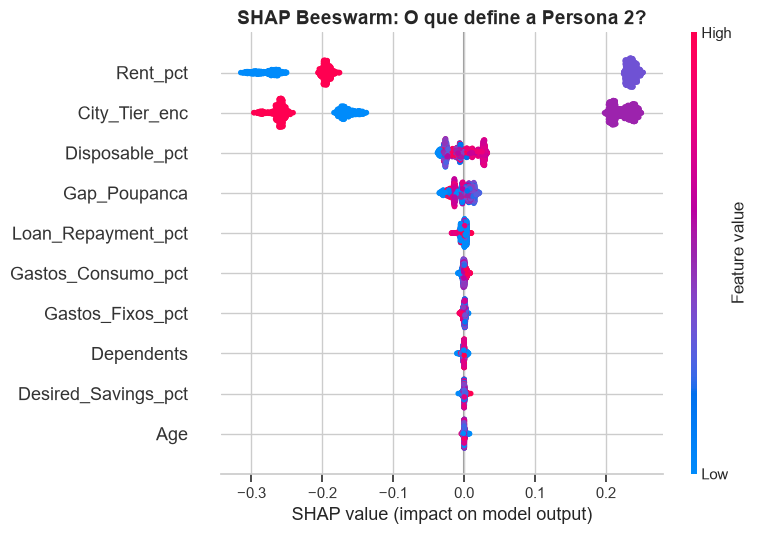

In [20]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# 1. Preparação dos dados do HDBSCAN (Removendo ruído e evitando vazamento)
colunas_para_remover = ['Cluster_HDBSCAN', 'Cluster']
df_limpo = df_final[df_final['Cluster_HDBSCAN'] != -1].copy()

y_alvo = df_limpo['Cluster_HDBSCAN']
X = df_limpo.drop(columns=[col for col in colunas_para_remover if col in df_limpo.columns])
feature_names = X.columns

# 2. Amostragem para performance do SHAP
tamanho_amostra = min(2000, len(X))
X_sample = X.sample(n=tamanho_amostra, random_state=42)
y_sample = y_alvo.loc[X_sample.index]

# 3. Treinamento do Modelo Substituto
rf_surrogate = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_surrogate.fit(X_sample, y_sample)

# 4. Cálculo dos valores SHAP originais
explainer = shap.TreeExplainer(rf_surrogate)
shap_values = explainer.shap_values(X_sample)

# 5. Tratamento de eixos para separar as Personas
if isinstance(shap_values, list):
    shap_values_array = np.transpose(np.array(shap_values), (1, 2, 0))
else:
    shap_values_array = np.array(shap_values)

# 6. Plotagem de UM Beeswarm exclusivo por Persona
n_personas = shap_values_array.shape[2]

for cluster_idx in range(n_personas):
    plt.figure(figsize=(10, 5))
    shap.summary_plot(
        shap_values_array[:, :, cluster_idx], # Pega APENAS o impacto para a Persona atual
        X_sample,
        feature_names=feature_names,
        plot_type='dot',
        show=False,
        color_bar=True
    )
    plt.title(f'SHAP Beeswarm: O que define a Persona {cluster_idx}?', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


### 2.8 Limpeza — Remoção de Colunas Temporárias

Remove colunas auxiliares adicionadas ao df_modelo durante o DBSCAN para não contaminar o Bloco 3.

In [21]:
# Remove colunas do HDBSCAN do df_modelo para não contaminar o K-Means
df_modelo.drop(columns=[c for c in ['Cluster_HDBSCAN', 'Cluster_str']
                         if c in df_modelo.columns], inplace=True)
print("Colunas removidas. df_modelo limpo para o Bloco 3.")
print(f"Colunas atuais: {df_modelo.columns.tolist()}")

# Limpa variáveis de escopo do HDBSCAN para evitar uso acidental no Bloco 3
for _var in ['rf_surrogate', 'shap_values', 'feature_names', 'X_sample', 'y_sample', 'explainer']:
    if _var in dir():
        del globals()[_var]
print("Variáveis de escopo do HDBSCAN removidas.")

Colunas removidas. df_modelo limpo para o Bloco 3.
Colunas atuais: ['Rent_pct', 'Loan_Repayment_pct', 'Disposable_pct', 'Desired_Savings_pct', 'Age', 'Dependents', 'Gap_Poupanca', 'City_Tier_enc', 'Gastos_Consumo_pct', 'Gastos_Fixos_pct']
Variáveis de escopo do HDBSCAN removidas.



## Bloco 3 — K-Means++
### 3.1 Seleção do Número de Clusters — Elbow e Silhouette Score

Testamos K de 2 a 10 avaliando inércia (Método do Cotovelo) e Silhouette Score médio para identificar o intervalo de K candidatos.

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Garanta que a limpeza aconteça ANTES dos testes
mask_limpo = df_final['Cluster_HDBSCAN'] != -1
df_pca_limpo = df_pca[mask_limpo]

inertias = []
silhouettes = []
K_range = range(2, 11)

print("Testando valores de K nos dados LIMPOS...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_pca_limpo)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(df_pca_limpo, labels, sample_size=3000))
    print(f"  K={k} | Inércia: {kmeans.inertia_:.0f} | Silhouette: {silhouettes[-1]:.4f}")

print("\nConcluído!")

Testando valores de K nos dados LIMPOS...
  K=2 | Inércia: 59987 | Silhouette: 0.2315
  K=3 | Inércia: 52786 | Silhouette: 0.2177
  K=4 | Inércia: 48344 | Silhouette: 0.2177
  K=5 | Inércia: 44087 | Silhouette: 0.1833
  K=6 | Inércia: 40482 | Silhouette: 0.1871
  K=7 | Inércia: 38427 | Silhouette: 0.1764
  K=8 | Inércia: 36818 | Silhouette: 0.1665
  K=9 | Inércia: 35275 | Silhouette: 0.1666
  K=10 | Inércia: 33913 | Silhouette: 0.1643

Concluído!


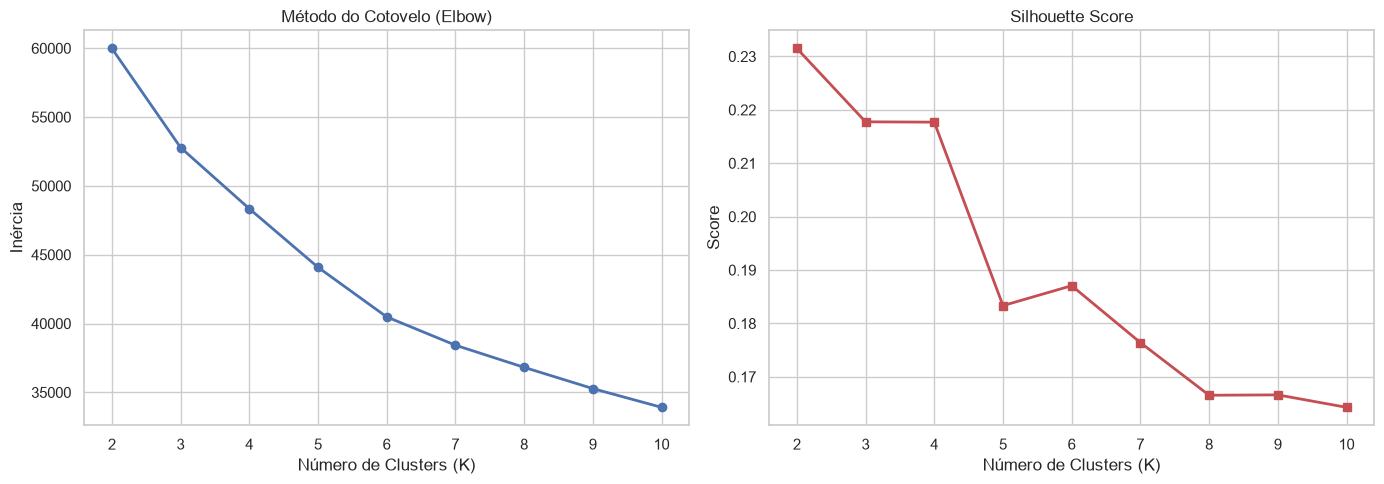

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico do Cotovelo
axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_title('Método do Cotovelo (Elbow)')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inércia')
axes[0].grid(True)

# Gráfico Silhouette
axes[1].plot(K_range, silhouettes, 'rs-', linewidth=2)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Score')
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 3.2 Silhouette Diagram — Análise por Cluster

O Silhouette Diagram avalia a qualidade individual de cada cluster para K=3, 4 e 5. A linha vermelha representa o coeficiente médio — clusters com área predominantemente à direita são bem formados e coesos.

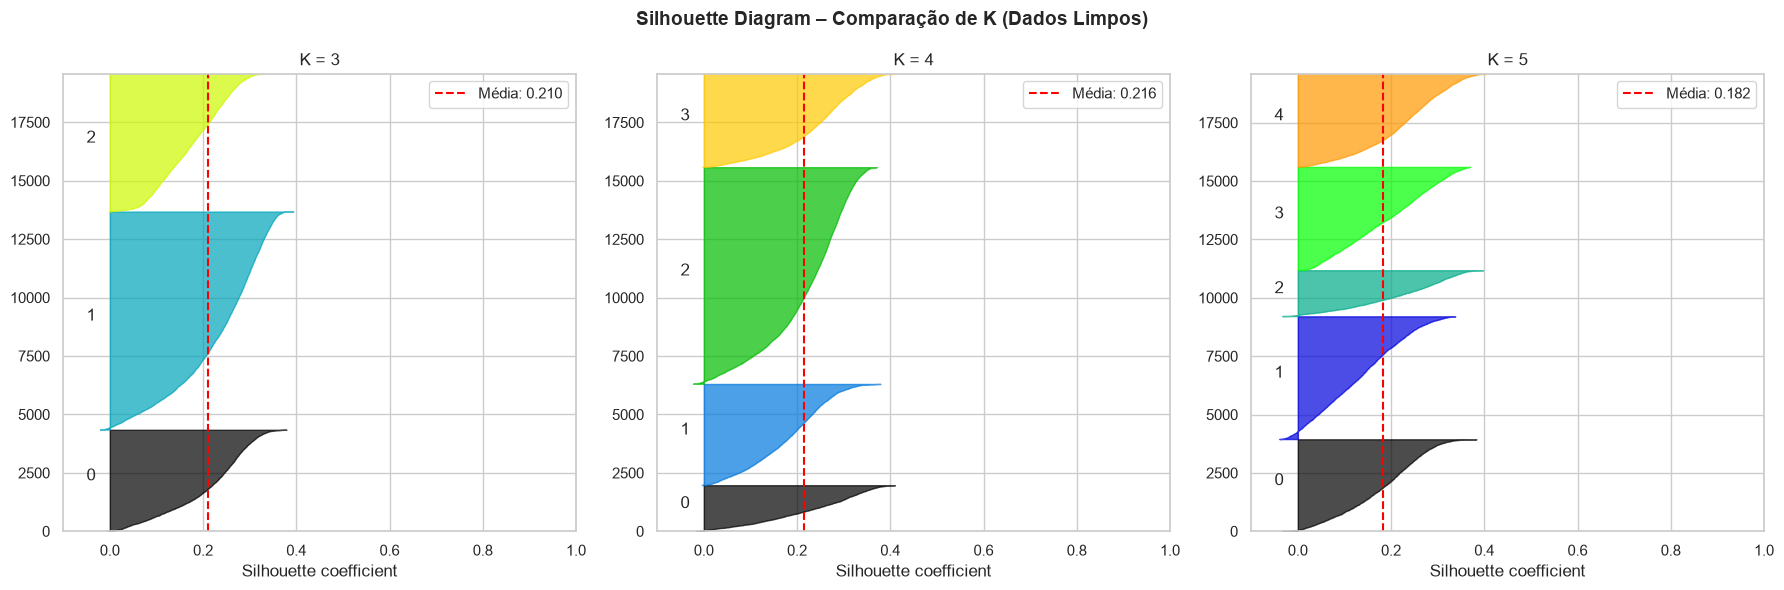

In [24]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm
import numpy as np
import matplotlib.pyplot as plt

def plot_silhouette(X, labels, k, ax):
    sil_vals = silhouette_samples(X, labels)
    ax.set_xlim([-0.1, 1])
    ax.set_ylim([0, len(X) + (k + 1) * 10])
    y_lower = 10
    for i in range(k):
        cluster_vals = np.sort(sil_vals[labels == i])
        size_cluster = cluster_vals.shape[0]
        y_upper = y_lower + size_cluster
        color = cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_cluster, str(i))
        y_lower = y_upper + 10
    avg = sil_vals.mean()
    ax.axvline(x=avg, color="red", linestyle="--", label=f'Média: {avg:.3f}')
    ax.set_xlabel('Silhouette coefficient')
    ax.set_title(f'K = {k}')
    ax.legend()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for idx, k in enumerate([3, 4, 5]):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    lbl = km.fit_predict(df_pca_limpo)
    plot_silhouette(df_pca_limpo, lbl, k, axes[idx])

plt.suptitle('Silhouette Diagram – Comparação de K (Dados Limpos)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Modelo Final — K-Means++ com K=4

In [25]:
# 1. Isolar apenas os usuários que não foram classificados como ruído pelo HDBSCAN
mask_limpo = df_final['Cluster_HDBSCAN'] != -1
df_pca_limpo = df_pca[mask_limpo]

# 2. Treinar o KMeans APENAS nos dados limpos
modelo_final = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
labels_final = modelo_final.fit_predict(df_pca_limpo)

# 3. Inicializar a coluna 'Cluster' com -1 (para manter o registro do ruído)
df['Cluster'] = -1
df_modelo['Cluster'] = -1

# 4. Mapear os resultados do KMeans apenas para as linhas correspondentes aos dados limpos
df.loc[mask_limpo, 'Cluster'] = labels_final
df_modelo.loc[mask_limpo, 'Cluster'] = labels_final

print("Modelo híbrido pronto!\n")
# Contagem atualizada (excluindo os ruídos marcados como -1)
contagem_valida = df_modelo[df_modelo['Cluster'] != -1]['Cluster'].value_counts().sort_index()
for cluster, qtd in contagem_valida.items():
    print(f"  Cluster {cluster}: {qtd} pessoas ({qtd/mask_limpo.sum()*100:.1f}%)\n")

Modelo híbrido pronto!

  Cluster 0: 1962 pessoas (10.0%)

  Cluster 1: 4324 pessoas (22.1%)

  Cluster 2: 9270 pessoas (47.4%)

  Cluster 3: 3987 pessoas (20.4%)



### 3.4 Visualização dos Clusters no Espaço PCA 2D

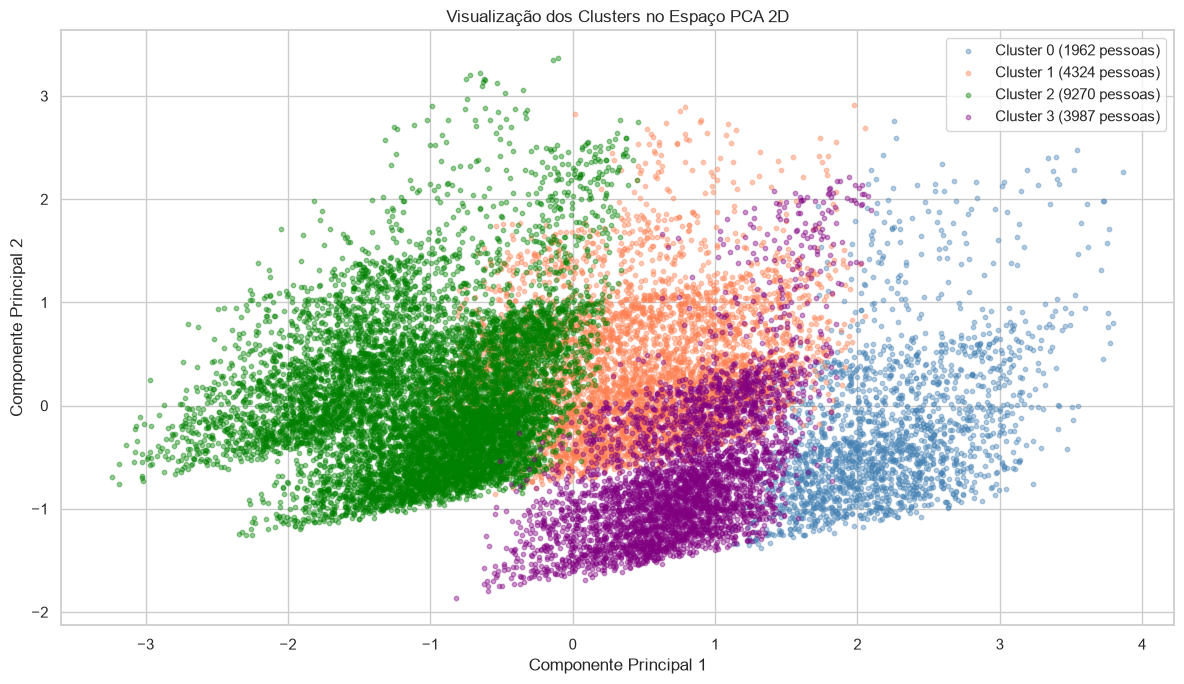

In [26]:
cores_cluster = {0: 'steelblue', 1: 'coral', 2: 'green', 3: 'purple'}
cores_pontos = [cores_cluster[l] for l in labels_final]

plt.figure(figsize=(12, 7))
for cluster in range(4):
    mask = labels_final == cluster
    plt.scatter(df_pca_2d[mask_limpo][mask, 0], df_pca_2d[mask_limpo][mask, 1],
                c=cores_cluster[cluster], alpha=0.4, s=10,
                label=f'Cluster {cluster} ({mask.sum()} pessoas)')

plt.title('Visualização dos Clusters no Espaço PCA 2D')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.tight_layout()
plt.show()

### 3.5 Radar Chart — Perfil Comportamental por Persona

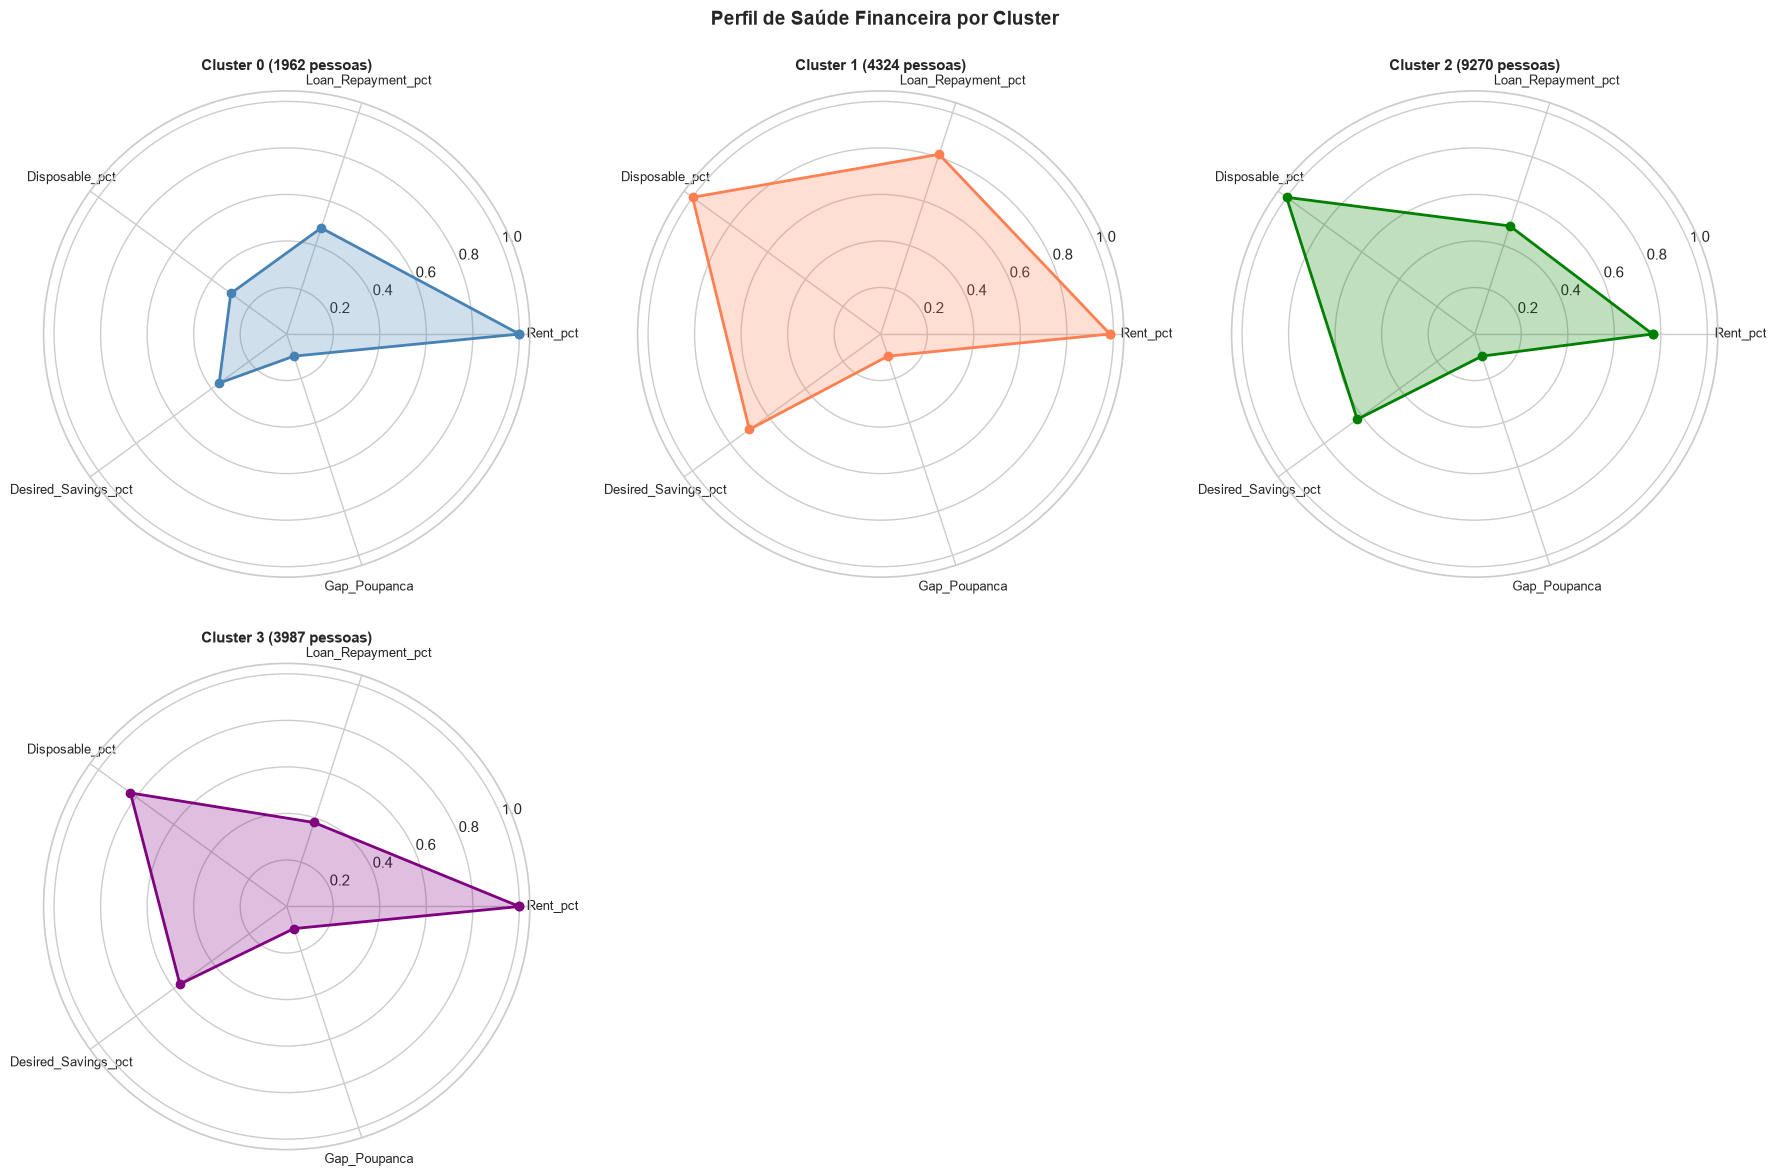

In [28]:
import matplotlib.pyplot as plt
import numpy as np

categorias_radar = ['Rent_pct', 'Loan_Repayment_pct', 'Disposable_pct',
                    'Desired_Savings_pct', 'Gap_Poupanca']

perfil_radar = perfil_clusters[categorias_radar].copy()
from sklearn.preprocessing import MinMaxScaler
scaler_radar = MinMaxScaler(feature_range=(0.1, 1.0))
perfil_norm = pd.DataFrame(
    scaler_radar.fit_transform(perfil_radar.T).T,
    index=perfil_radar.index,
    columns=perfil_radar.columns
)

N = len(categorias_radar)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()
cores = ['steelblue', 'coral', 'green', 'purple', 'orange']
contagem = df_personas['Cluster'].value_counts().sort_index()

for i in range(4):
    valores = perfil_norm.iloc[i].values.tolist()
    valores += valores[:1]
    axes[i].plot(angles, valores, 'o-', linewidth=2, color=cores[i])
    axes[i].fill(angles, valores, alpha=0.25, color=cores[i])
    axes[i].set_xticks(angles[:-1])
    axes[i].set_xticklabels(categorias_radar, size=9)
    axes[i].set_title(f'Cluster {i} ({contagem[i]} pessoas)',
                      size=11, fontweight='bold', pad=15)

axes[4].set_visible(False)
axes[5].set_visible(False)
plt.suptitle('Perfil de Saúde Financeira por Cluster', size=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
PERSONAS = {
    0: {'nome': 'Cluster 0', 'cor': '#4C9BE8'},
    1: {'nome': 'Cluster 1', 'cor': '#E8834C'},
    2: {'nome': 'Cluster 2', 'cor': '#4CAF50'},
    3: {'nome': 'Cluster 3', 'cor': '#9B59B6'},
}

print("Personas atualizadas:")
for k, v in PERSONAS.items():
    print(f"  Cluster {k} — {v['nome']}")

Personas atualizadas:
  Cluster 0 — Cluster 0
  Cluster 1 — Cluster 1
  Cluster 2 — Cluster 2
  Cluster 3 — Cluster 3


### 3.7 Interpretabilidade: SHAP Values

Modelo substituto Random Forest treinado com os labels do K-Means++ para calcular a importância das variáveis via SHAP. A acurácia do surrogate indica o quão bem ele reproduz as fronteiras do K-Means no espaço original.

In [30]:
from sklearn.ensemble import RandomForestClassifier
import shap

df_limpo_kmeans = df_modelo[df_modelo['Cluster'] != -1]
X_shap = df_limpo_kmeans.drop(columns=[c for c in ['Cluster', 'Cluster_HDBSCAN', 'Cluster_str']
                                  if c in df_limpo_kmeans.columns])
feature_names = X_shap.columns.tolist()

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, max_depth=10)
rf.fit(X_shap, labels_final)
print(f"RF surrogate accuracy: {rf.score(X_shap, labels_final):.3f}")

RF surrogate accuracy: 1.000


In [31]:
sample_idx  = np.random.RandomState(42).choice(len(X_shap), 2000, replace=False)
X_sample    = X_shap.iloc[sample_idx]
lbl_sample  = labels_final[sample_idx]

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)
print(f"SHAP calculado. Shape: {np.array(shap_values).shape}")

SHAP calculado. Shape: (2000, 10, 4)


### 3.8 Princípio de Pareto — Comprometimento Financeiro por Persona

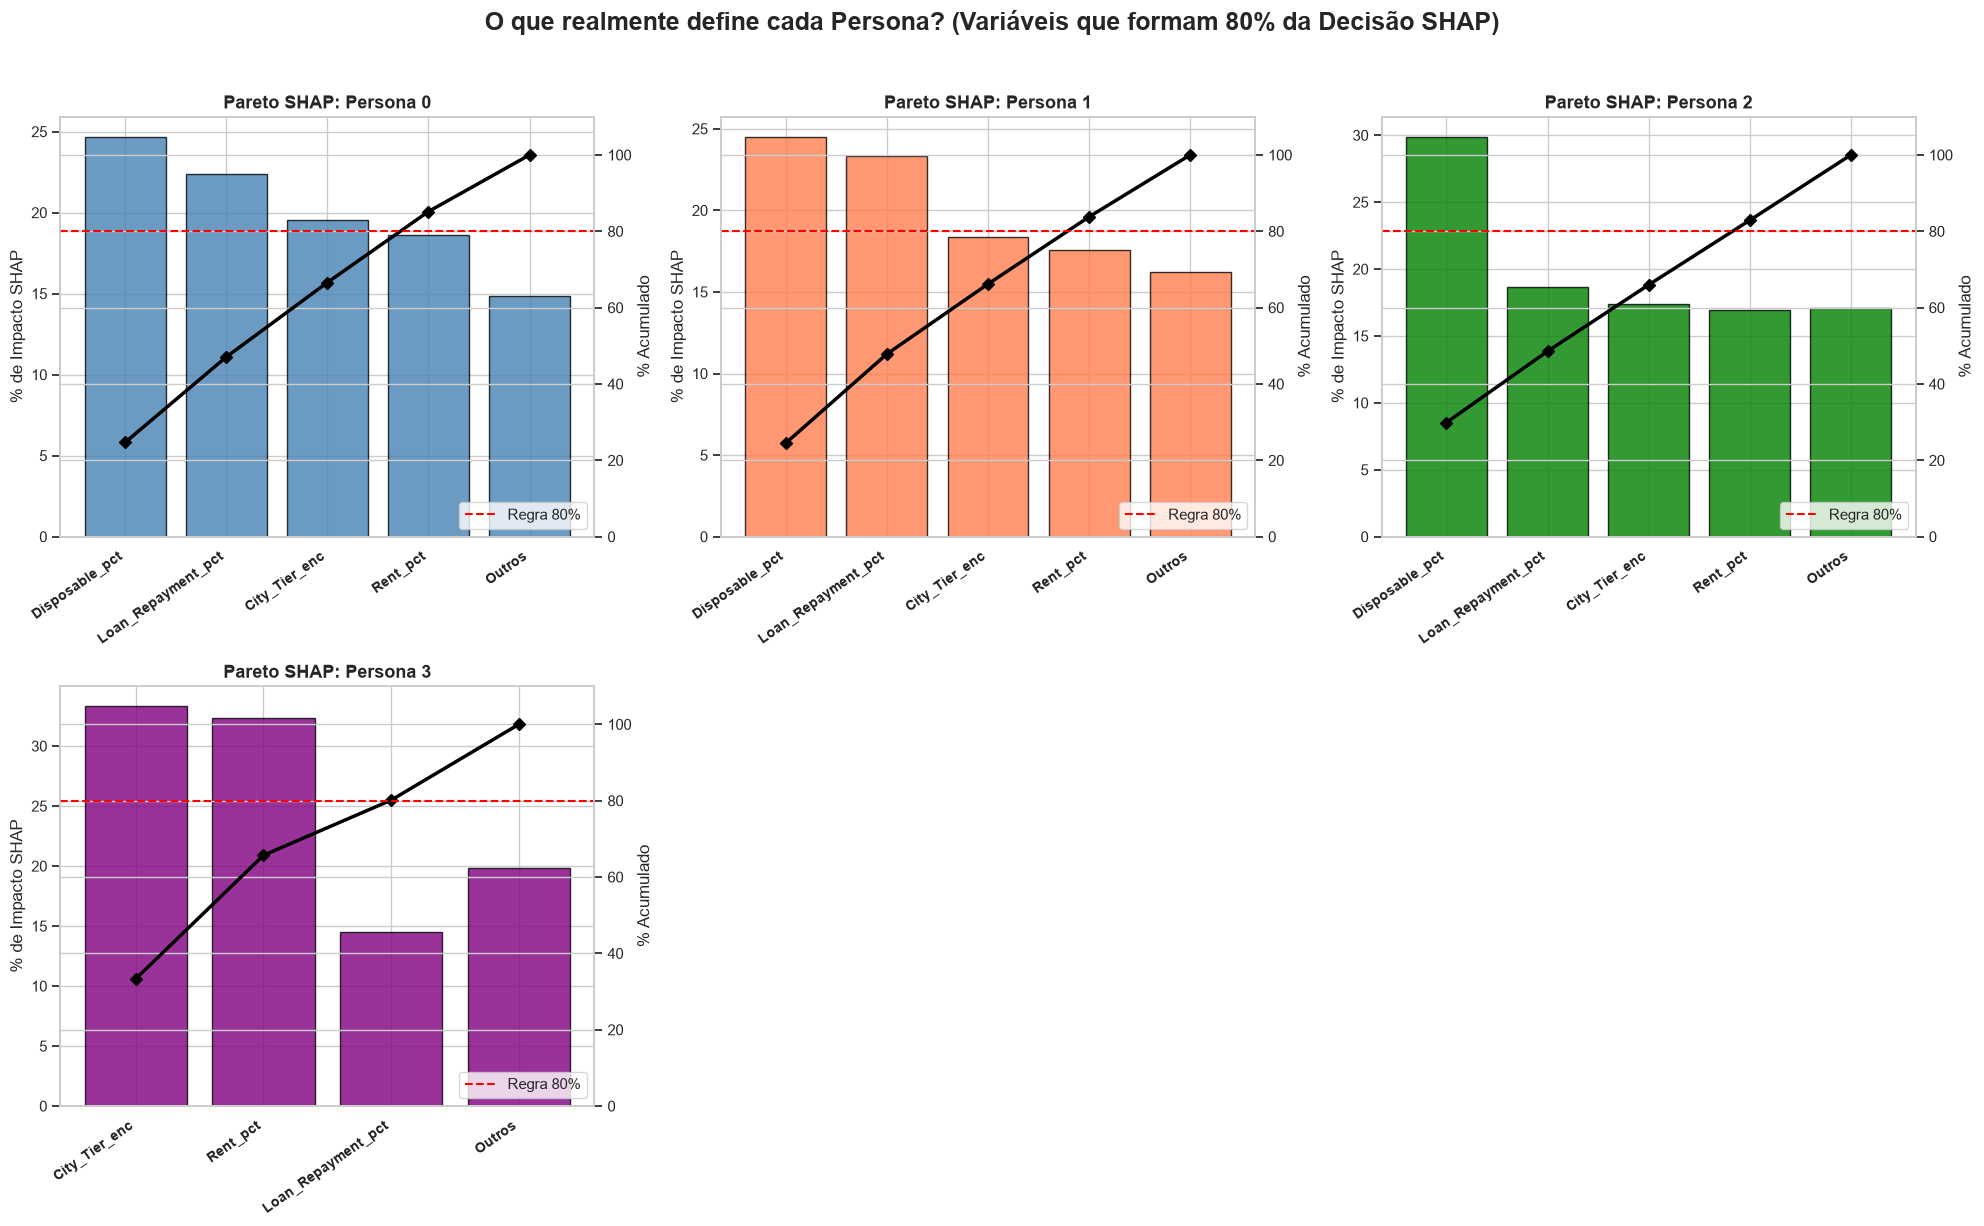

In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 0. Paleta de cores oficial do seu projeto para os clusters
cores_projeto = ['steelblue', 'coral', 'green', 'purple', 'orange']

# 1. Configuração Responsiva do Grid (Ajusta linhas e colunas conforme a qtd real de personas)
cols = 3
rows = int(np.ceil(len(rf.classes_) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(20, 6 * rows))
axes = np.atleast_1d(axes).flatten()

# 2. Iteração blindada usando os clusters que o modelo SHAP realmente reconheceu
for i, k in enumerate(rf.classes_):

    # Extração dos valores SHAP (resolvendo os erros de matriz anteriores)
    if isinstance(shap_values, list):
        mean_abs_shap = np.abs(shap_values[i]).mean(axis=0)
    elif len(np.array(shap_values).shape) == 3:
        mean_abs_shap = np.abs(np.array(shap_values)[:, :, i]).mean(axis=0)
    else:
        mean_abs_shap = np.abs(shap_values[:, :, i]).mean(axis=0)

    # DataFrame de Importância Original (todas as 10 variáveis brutas)
    df_imp = pd.DataFrame({
        'Feature': feature_names,
        'Mean_Abs_SHAP': mean_abs_shap
    }).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

    # 3. Matemática do Princípio de Pareto (Corte dos 80%)
    total_shap = df_imp['Mean_Abs_SHAP'].sum()
    df_imp['Percentual'] = (df_imp['Mean_Abs_SHAP'] / total_shap) * 100
    df_imp['Cumulativo'] = df_imp['Percentual'].cumsum()

    # Selecionamos as variáveis até que o cumulativo BATA ou PASSE de 80% pela primeira vez
    cumsum_antes = df_imp['Percentual'].cumsum().shift(fill_value=0)
    linhas_principais = df_imp[cumsum_antes < 80].copy()
    linhas_outros = df_imp[~df_imp.index.isin(linhas_principais.index)]

    # Criar a barra "Outros" se houver variáveis fora do corte
    if not linhas_outros.empty:
        df_outros = pd.DataFrame({
            'Feature': ['Outros'],
            'Mean_Abs_SHAP': [linhas_outros['Mean_Abs_SHAP'].sum()],
            'Percentual': [linhas_outros['Percentual'].sum()],
            'Cumulativo': [100.0]
        })
        df_pareto = pd.concat([linhas_principais, df_outros], ignore_index=True)
    else:
        df_pareto = linhas_principais.copy()

    # Recalcular cumulativo final por segurança para o gráfico
    df_pareto['Cumulativo'] = df_pareto['Percentual'].cumsum()

    # 4. Plotagem Individual do Subplot
    ax = axes[i]

    # AQUI ESTÁ A CORREÇÃO: Selecionando a cor original do cluster (com prevenção para não faltar cor se houver >5 clusters)
    cor_cluster = cores_projeto[k % len(cores_projeto)]

    # Barras principais agora usam a cor do respectivo cluster
    ax.bar(range(len(df_pareto)), df_pareto['Percentual'], color=cor_cluster, alpha=0.8, edgecolor='black')

    # Linha do Cumulativo continua preta para manter o contraste do Pareto
    ax2 = ax.twinx()
    ax2.plot(range(len(df_pareto)), df_pareto['Cumulativo'], color='black', marker='D', linewidth=2.5)

    # Linha Vermelha de Meta (80%)
    ax2.axhline(y=80, color='red', linestyle='--', linewidth=1.5, label='Regra 80%')

    # Formatação Visual do Gráfico
    ax.set_xticks(range(len(df_pareto)))
    ax.set_xticklabels(df_pareto['Feature'], rotation=35, ha='right', fontsize=10, fontweight='bold')
    ax.set_title(f'Pareto SHAP: Persona {k}', fontweight='bold', fontsize=13)
    ax.set_ylabel('% de Impacto SHAP')
    ax2.set_ylabel('% Acumulado')
    ax2.set_ylim(0, 110)
    ax2.legend(loc='lower right')

# 5. Ocultar dinamicamente os quadros vazios do grid (Caso o grid tenha espaços extras)
for j in range(len(rf.classes_), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('O que realmente define cada Persona? (Variáveis que formam 80% da Decisão SHAP)',
             size=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


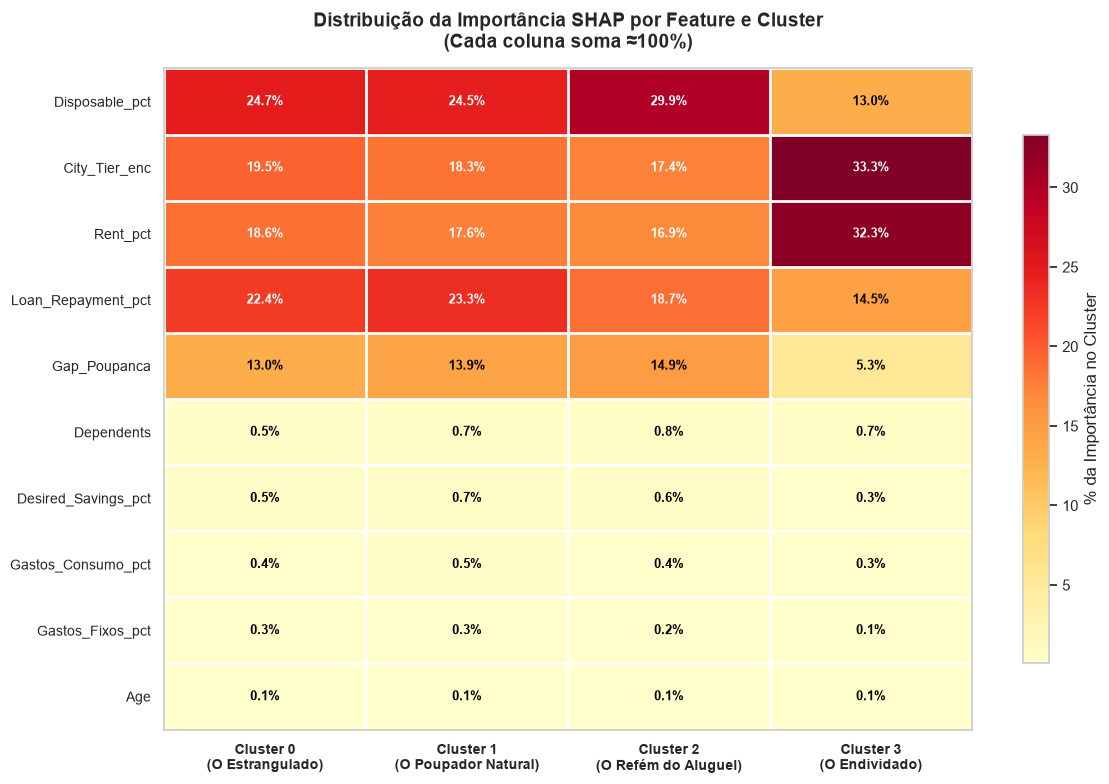


✅ Heatmap gerado com sucesso!


In [33]:
# =============================================================================
# CÉLULA 2: Heatmap de Importância SHAP por Cluster (Grid Corrigido)
# =============================================================================

# Construir matriz features × clusters
n_clusters = len(rf.classes_)
heatmap_matrix = np.zeros((len(feature_names), n_clusters))
shap_arr = np.array(shap_values)
for i, k in enumerate(rf.classes_):
    if isinstance(shap_values, list):
        heatmap_matrix[:, i] = np.abs(shap_values[i]).mean(axis=0)
    else:
        heatmap_matrix[:, i] = np.abs(shap_arr[:, :, i]).mean(axis=0)

# Normalizar por cluster (cada coluna soma 100%)
col_sums = heatmap_matrix.sum(axis=0)
heatmap_pct = (heatmap_matrix / col_sums * 100)

# Ordenar features pela importância global média
global_importance = heatmap_pct.mean(axis=1)
sorted_idx = np.argsort(global_importance)[::-1]
heatmap_pct_sorted = heatmap_pct[sorted_idx]
feature_names_sorted = [feature_names[i] for i in sorted_idx]

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(heatmap_pct_sorted, cmap='YlOrRd', aspect='auto')

# Labels e nomes definidos pela Análise de Pareto
nomes_clusters = {
    0: 'O Estrangulado',
    1: 'O Poupador Natural',
    2: 'O Refém do Aluguel',
    3: 'O Endividado',
}

ax.set_xticks(range(n_clusters))
labels_x = [f'Cluster {k}\n({nomes_clusters[k]})' for k in range(n_clusters)]
ax.set_xticklabels(labels_x, fontsize=10, fontweight='bold')
ax.set_yticks(range(len(feature_names_sorted)))
ax.set_yticklabels(feature_names_sorted, fontsize=10)

# Anotar valores
for i in range(len(feature_names_sorted)):
    for j in range(n_clusters):
        val = heatmap_pct_sorted[i, j]
        color = 'white' if val > 15 else 'black'
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                fontsize=9, fontweight='bold', color=color)

# Corrigir o grid:
# 1. Desativar o grid principal que cruza no meio do texto
ax.grid(False)
# 2. Criar um grid alinhado nas bordas de cada célula usando "minor ticks"
ax.set_xticks(np.arange(n_clusters + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(len(feature_names_sorted) + 1) - 0.5, minor=True)
ax.grid(which="minor", color="white", linestyle='-', linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)

ax.set_title('Distribuição da Importância SHAP por Feature e Cluster\n'
             '(Cada coluna soma ≈100%)',
             fontsize=14, fontweight='bold', pad=15)

plt.colorbar(im, ax=ax, label='% da Importância no Cluster', shrink=0.8)
plt.tight_layout()
plt.show()

print("\n✅ Heatmap gerado com sucesso!")


#### 3.9 Beeswarm Global

Importância global das variáveis com direção de impacto: média sobre todas as classes. Variáveis no topo são as mais discriminantes entre as personas.

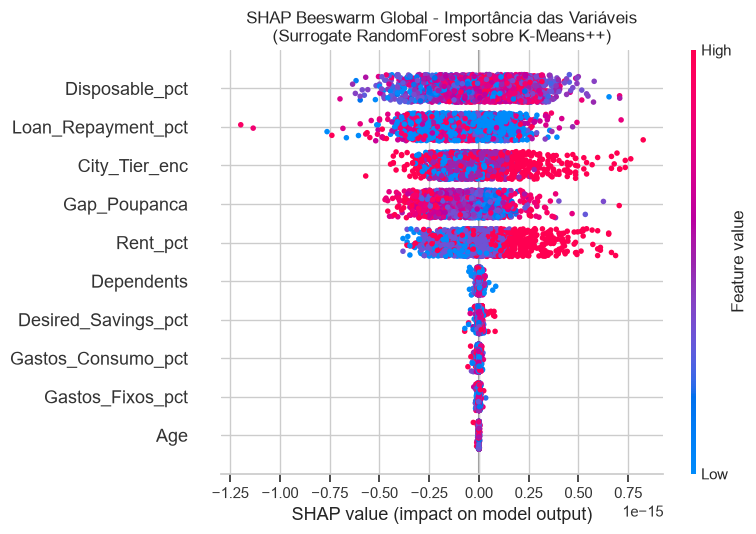

In [34]:
# Beeswarm global sem valor absoluto
# Mostra direção real do impacto de cada variável
shap_values_array = np.array(shap_values)

# Média sobre as classes para mostrar impacto geral
shap_mean = shap_values_array.mean(axis=2)

plt.figure(figsize=(10, 5))
shap.summary_plot(shap_mean, X_sample, feature_names=feature_names,
                  plot_type='dot', show=False, color_bar=True)
plt.title('SHAP Beeswarm Global - Importância das Variáveis\n'
          '(Surrogate RandomForest sobre K-Means++)')
plt.tight_layout()
plt.show()

#### 3.9.1. Beeswarm por Cluster

Importância das variáveis para cada persona individualmente, permite entender o que define cada cluster especificamente. Esse gráfico utiliza todos os pontos da análise, permitindo analisar valores negativos de SHAP, ou seja, que fizeram com que determinados pontos não se encaixassem nesse cluster.

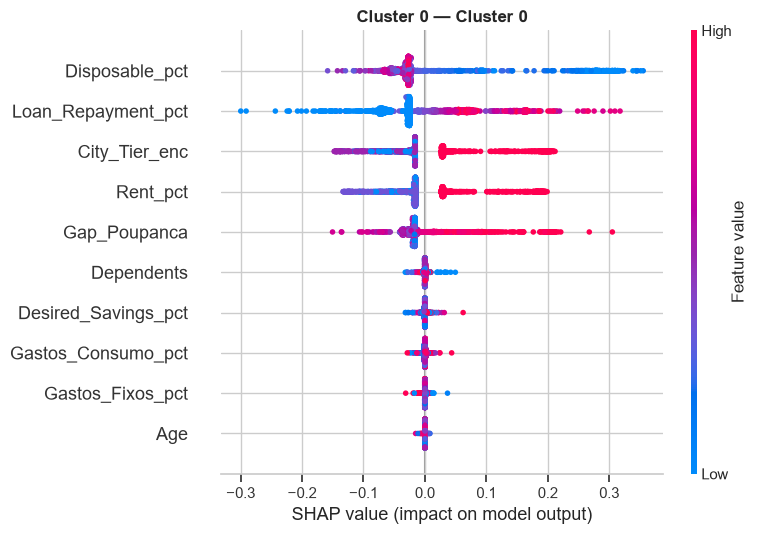

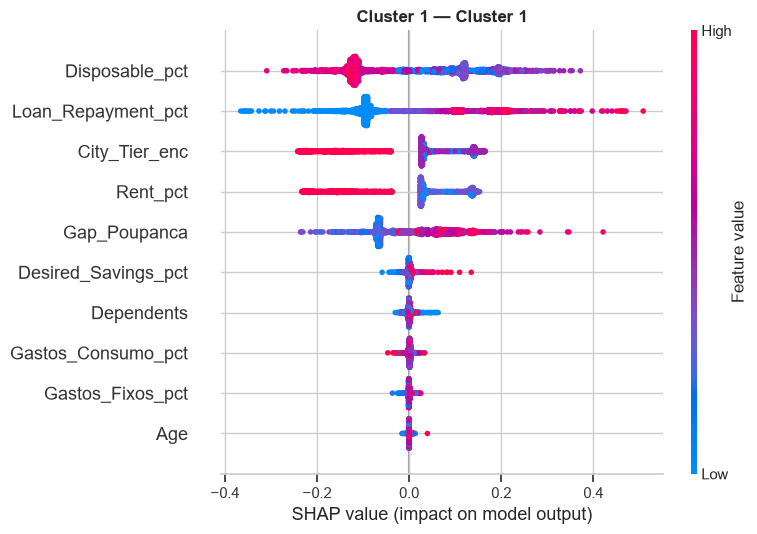

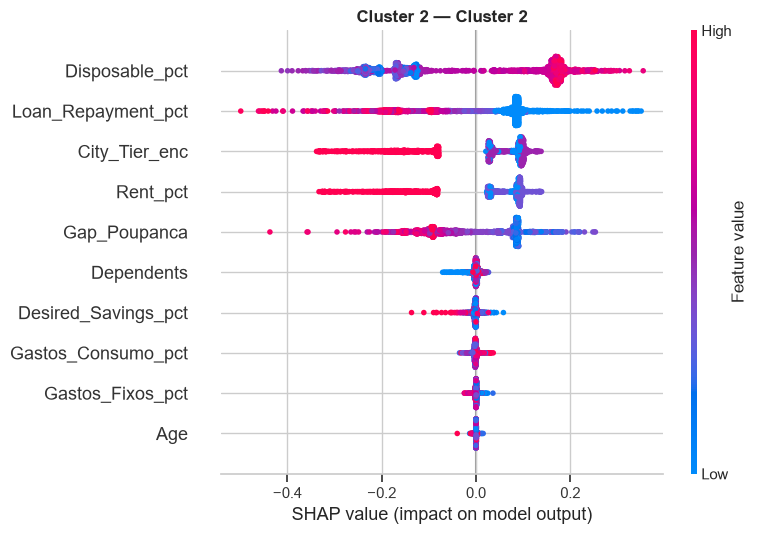

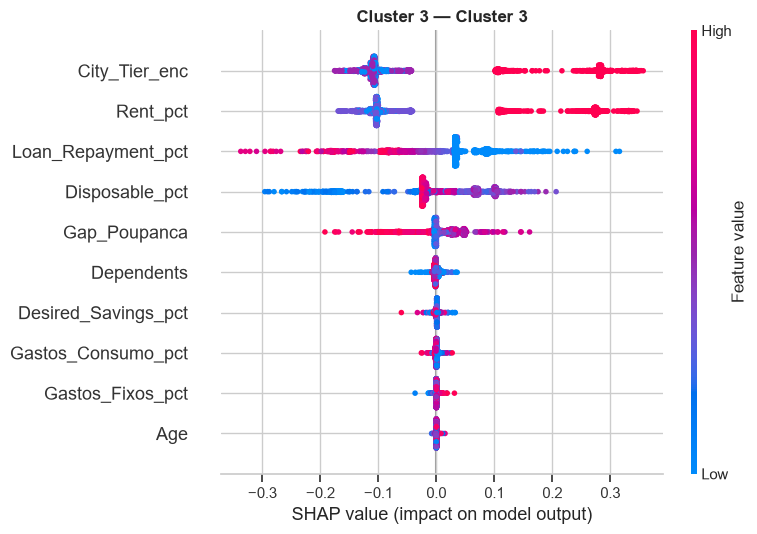

In [35]:
# Gráfico por cluster corrigido (sem a máscara)
shap_values_array = np.array(shap_values)

for c in range(4):
    # Pega a "fatia" do SHAP apenas da classe c, mas para TODOS os clientes
    shap_c = shap_values_array[:, :, c]

    plt.figure(figsize=(10, 5))
    shap.summary_plot(shap_c, X_sample, feature_names=feature_names,
                      plot_type='dot', show=False, color_bar=True)
    plt.title(f"Cluster {c} — {PERSONAS[c]['nome']}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


### 3.10 Conclusão

Salvamento do pipeline completo (scaler, PCA, modelo, personas e métricas) em arquivo `.pkl` para uso em produção ou inferência futura.

In [36]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_final = silhouette_score(df_pca_limpo, labels_final, sample_size=3000, random_state=42)
db_final  = davies_bouldin_score(df_pca_limpo, labels_final)

print("=== MÉTRICAS OFICIAIS DO MODELO HÍBRIDO (K=4) ===")
print(f"Silhouette: {sil_final:.4f} | Davies-Bouldin: {db_final:.4f}")

=== MÉTRICAS OFICIAIS DO MODELO HÍBRIDO (K=4) ===
Silhouette: 0.2161 | Davies-Bouldin: 1.6161
